<a href="https://colab.research.google.com/github/zahidjkuai/Computer_Vision_Tasks/blob/main/AI_Image_Captioning_with_Qwen2_5VL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 21.0 MB/s eta 0:00:00


**Imports**

In [ ]:
# ── Standard library ────────────────────────────────────────────
import os          # File‑system helpers (paths, env vars, etc.)
import random      # Lightweight randomness (e.g. sample prompts)
import textwrap    # Nicely format long strings for display
import io          # In‑memory byte streams (e.g. image buffers)
import requests    # Simple HTTP requests for downloading assets

# ── Numerical computing ─────────────────────────────────────────
import numpy as np  # Core array maths (fast, vectorised operations)

# ── Deep‑learning stack ─────────────────────────────────────────
import torch  # Tensor library + GPU acceleration
from transformers import (
    Qwen2_5_VLForConditionalGeneration,  # Multimodal LLM (image+text)
    AutoProcessor,                       # Paired tokenizer/feature‑extractor
)

# ── Imaging & visualisation ─────────────────────────────────────
from PIL import Image                    # Pillow: load/save/manipulate images
import matplotlib.pyplot as plt          # Quick plots in notebooks
import matplotlib.patches as patches     # Bounding‑box overlays, etc.

# ── Project‑specific helpers ────────────────────────────────────
from qwen_vl_utils import process_vision_info  # Post‑process Qwen outputs

# ── Notebook conveniences ──────────────────────────────────────
import IPython.display as ipd             # Inline display (images, audio, HTML)

**Device and Model Load**

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype="auto",     # automatically uses FP16 on GPU, FP32 on CPU
    device_map="auto"       # dispatches layers to the available device(s)
)
processor = AutoProcessor.from_pretrained(model_id)

print(f"Model loaded on: {model.device}")

`torch_dtype` is deprecated! Use `dtype` instead!
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.53G [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

Model loaded on: cuda:0


**Load Image**

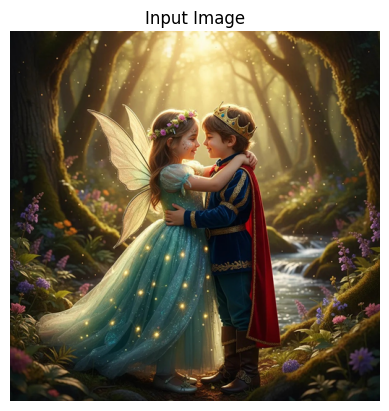

In [ ]:
def resize_with_aspect_ratio(image, target_size=(512, 512), fill_color=(0, 0, 0)):
    image.thumbnail(target_size, Image.Resampling.LANCZOS)

    # Create new image with target size and fill color
    new_image = Image.new("RGB", target_size, fill_color)
    paste_position = (
        (target_size[0] - image.width) // 2,
        (target_size[1] - image.height) // 2
    )
    new_image.paste(image, paste_position)
    return new_image
img_dir = r"/vlm_sample.jpg"
img = Image.open(img_dir).convert("RGB")
img = resize_with_aspect_ratio(img)
plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

**5 Build a Chat Style prompt**

5.1 Create a message in JSON format
The processor turns these messages into plain text (with special tokens) and extracts the visual tensors so the model receives both modalities.

In [ ]:
msgs = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": "Describe this image."}
        ],
    }
]

### 5.2 Apply Chat Template
Every chat model ships with a pattern. The above JSON format needs to be converted to this template and this is done using `apply_chat_template`. It performs three tasks.
1. **Reads the model’s chat template**: Qwen 2.5VL has a chat template that looks like `<|im_start|>{role}\n{content}<|im_end|>`.
2. **Fills in the template with the msgs list**. It loops over each message, swaps in the role (user, assistant, etc.) and the content (text plus special <image> markers), and concatenates the result into one long string.
3. **Adds the “assistant starts talking now” marker** (add_generation_prompt=True). At the end it appends `<|im_start|>assistant`

We have also instructed it to NOT tokenize the text because we are going to use the processor to process text and images together, and tokenization will be performed in that step.

In [ ]:
# Build the full textual prompt that Qwen-VL expects
# --------------------------------------------------
# • msgs : list of message dicts (roles + content, including <image> markers)
# • tokenize=False : return a plain string—not token IDs—so we can
#                    combine it with image tensors in the next processor() call
# • add_generation_prompt=True : appends the “assistant is about to speak” marker
#                                (e.g. "<|im_start|>assistant\n"), which tells the
#                                model where its reply should begin.
text_prompt = processor.apply_chat_template(
    msgs,
    tokenize=False,
    add_generation_prompt=True
)

# For sanity-checking: print the raw prompt string that will be fed to the model
print(text_prompt)

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Describe this image.<|im_end|>
<|im_start|>assistant



### 5.3 Extract image inputs from `msg`

In the previous step we converted our message `msg` from JSON format to the chat template the model understands.

Now, we need to extract images and videos from `msg` using `process_vision_info` utility. It performs the following tasks
1. Walks through every message,
2. Finds all `"image"` entries,
3. Applies the Qwen-VL visual pre-processing to ensure each image is a PIL.Image ( is a list / tensor of frames).
4. Returns two parallel lists/tensors
 - `image_inputs`  → batched image tensors (or [] if none)

In [ ]:
# Extract vision-modalities from msgs and convert them to model-ready tensors
image_inputs, video_inputs = process_vision_info(msgs)


**6 Generate the Caption**

**6.1 Run Inference**

In [ ]:
# ── Pack text + vision into model-ready tensors ──────────────────────────────
inputs = processor(
    text=[text_prompt],      # 1-element batch containing the chat prompt string
    images=image_inputs,     # list of raw PIL images (pre-processed inside processor)
    videos=video_inputs,     # list of raw video clips (if any)
    padding=True,            # pad sequences so text/vision tokens line up in a batch
    return_tensors="pt",     # return a dict of PyTorch tensors (input_ids, pixel_values, …)
).to(model.device)           # move every tensor—text & vision—to the model’s GPU/CPU

# ── Run inference (no gradients, pure generation) ───────────────────────────
with torch.no_grad():                     # disable autograd to save memory
    generated_ids = model.generate(       # autoregressive decoding
        **inputs,                         # unpack dict into generate(...)
        max_new_tokens=200                 # cap the response at 64 tokens
    )
print(inputs.input_ids[0])
print(generated_ids)

tensor([151644,   8948,    198,   2610,    525,    264,  10950,  17847,     13,
        151645,    198, 151644,    872,    198, 151652, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 

**Decode Output**

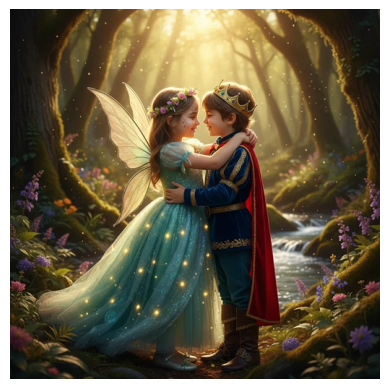

The image depicts a whimsical and enchanting scene set in a lush, magical forest. A young fairy with
delicate wings and a flower crown stands next to a young prince dressed in royal attire, complete
with a crown, a blue tunic, and a red cape. The fairy is wearing a flowing, light blue dress adorned
with sparkling lights, giving her a magical appearance. The prince is holding the fairy's hand
gently, and they seem to be sharing a tender moment amidst the vibrant, colorful flowers and the
soft glow of sunlight filtering through the trees. The overall atmosphere is one of wonder and
enchantment, capturing the essence of a fairy tale.


In [ ]:
# Extract the newly generated tokens (skip the prompt length)
caption = processor.batch_decode(
    generated_ids[:, inputs.input_ids.shape[-1]:],
    skip_special_tokens=True
)[0]

# Display the image
plt.imshow(img)
plt.axis("off")
plt.show()

# Print caption
width = 100
wrapped_caption = textwrap.fill(caption, width)
print(wrapped_caption)